# Skeleton Synapse Aassignment Preprocessing Final

# Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
import math
import logging, traceback, sys
import os
import glob
from tqdm import tqdm
import caveclient
import traceback
from meshparty import skeleton
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.patches as mpatches
import microns_datacleaner as mic
import microns_datacleaner.filters as fl
import matplotlib.cm as cm
import seaborn as sns
from standard_transform import minnie_ds
import cupy as xp
from scipy import stats
import plotly.graph_objects as go
sys.path.append(os.path.abspath('./analysis'))

# Import dendrite libraries
import dendrites as dd
import skeleton_plots as skp
import synapse_analysis as synapse_anal

# Caveclient setup
client = caveclient.CAVEclient('minnie65_public')
client.version = 1300

In [2]:
# == Path setup for reading and saving data ==
path_project = "/media/DATA1/CK/python_script/MicronsBinder_04"

In [3]:
# === annotation table ===
path_ann = "/data/data_raw/annotation_tables/"

proofreading_status_and_strategy_fname = "proofreading_status_and_strategy"
coregistration_manual_fname = "coregistration_manual_v4"
nucleus_detection_fname = "nucleus_detection_v0"
aibs_metamodel_celltypes_fname = "aibs_metamodel_celltypes_v661"
nucleus_functional_area_fname = "nucleus_functional_area_assignment"
functional_properties_fname = "functional_properties_v3_bcm"

proofreading_status_and_strategy = pd.read_pickle(path_project + path_ann + proofreading_status_and_strategy_fname)
coregistration_manual_v4 = pd.read_pickle(path_project + path_ann + coregistration_manual_fname)
nucleus_detection_v0 = pd.read_pickle(path_project + path_ann + nucleus_detection_fname)
aibs_metamodel_celltypes_v661 = pd.read_pickle(path_project + path_ann + aibs_metamodel_celltypes_fname)
nucleus_functional_area_assignment = pd.read_pickle(path_project + path_ann + nucleus_functional_area_fname)
functional_properties_v3_bcm = pd.read_pickle(path_project + path_ann + functional_properties_fname)

In [4]:
# ==== Neuron list - read from datacleaner ===
cleaner = mic.MicronsDataCleaner(datadir = "data", version=1300)   #Target version and download folder
cleaner.download_nucleus_data()    #Download the data
units, segments = cleaner.process_nucleus_data() #Process the downloaded data and segment into layers

Transform positions: 100%|████████████| 94014/94014 [00:00<00:00, 186767.30it/s]


In [5]:
# Filter neuron list

# Layer 23
units_23P = fl.filter_neurons(units, cell_type=["23P"], brain_area=["V1"])
units_23P_pt_root_id = units_23P["pt_root_id"].tolist()
print(f"Layer 23 = {len(units_23P_pt_root_id)}")

# Layer 4
units_4P = fl.filter_neurons(units, cell_type=["4P"], brain_area=["V1"])
units_4P_pt_root_id = units_4P["pt_root_id"].tolist()
print(f"Layer 4 = {len(units_4P_pt_root_id)}")

# Layer 5
units_5P = fl.filter_neurons(units, cell_type=["5P-ET", "5P-IT", "5P-NP"], brain_area=["V1"])
units_5P_pt_root_id = units_5P["pt_root_id"].tolist()
print(f"Layer 5 = {len(units_5P_pt_root_id)}")

Layer 23 = 13305
Layer 4 = 9940
Layer 5 = 7148


In [6]:
# ====== MAKE SURE TO CHANGE IT TO CORRECT LIST OF NEURONS BEFORE YOU PROCEED ========
list_neurons = units_23P_pt_root_id
print("Picked layer = units_23P_pt_root_id")

Picked layer = units_23P_pt_root_id


# Preprocessing

## Step 1: Removing neurons with Proximal Node Clustering
Removes neurons whose skeleton nodes fall within a specified radius threshold from the soma.
These are likely truncated or poorly reconstructed
This is just to filter out neurons, does not modify skeleton structure

In [8]:
# Calculate number of nodes within a certain radius
path_raw = "data/data_raw/skeleton/skeleton_raw_swc/"
soma_dist_all_neurons = {}

radii = np.arange(1, 21)

n_total = len(list_neurons)
n_ok = 0
missing = []
failed_other = []  # optional: for unexpected errors

for neuron in tqdm(list_neurons):
    fname = f"{neuron}_sk_swc_raw.csv"
    fpath = os.path.join(path_project, path_raw, fname)

    # --- skip cleanly if skeleton file doesn't exist ---
    if not os.path.exists(fpath):
        missing.append(neuron)
        continue

    try:
        # read raw skeleton
        sk_swc = pd.read_csv(
            fpath,
            low_memory=False,
            usecols=["id", "parent", "x", "y", "z"],
        )

        # Calculate distance to soma
        sk_swc = dd.soma_euclidean_dist(sk_swc)

        # Drop the soma row once so we don't need -1 later
        non_soma = sk_swc[sk_swc["parent"] != -1]

        # sort distances once
        dists = np.sort(non_soma["eucli_dist"].to_numpy())

        # cumulative counts: for each radius r, count of dists <= r
        counts = np.searchsorted(dists, radii, side="right").tolist()

        soma_dist_all_neurons[neuron] = counts
        n_ok += 1

    except Exception as e:
        # unexpected issues (corrupt csv, weird columns, dd error, etc.)
        failed_other.append((neuron, repr(e)))
        continue

# ---- report ----
n_missing = len(missing)
n_failed_other = len(failed_other)

print("\n=== Skeleton availability report ===")
print(f"Total neurons requested: {n_total}")
print(f"Skeleton found + processed: {n_ok}")
print(f"Missing skeleton files: {n_missing}")
print(f"Other failures (non-missing): {n_failed_other}")

# Save
path_save = "data/data_processed/neurons_23P_13305/step_1_proximal_node_clustering/"
os.makedirs(os.path.join(path_project, path_save), exist_ok=True)

out_path = os.path.join(path_project, path_save, "sanity_check_soma_radius.pkl")
with open(out_path, "wb") as f:
    pickle.dump(soma_dist_all_neurons, f)

# # Optional: save missing list for later debugging
# missing_path = os.path.join(path_project, path_save, "missing_skeleton_neurons.pkl")
# with open(missing_path, "wb") as f:
#     pickle.dump(missing, f)

# # Optional: save non-missing failures (helps debugging)
# failed_other_path = os.path.join(path_project, path_save, "failed_other_neurons.pkl")
# with open(failed_other_path, "wb") as f:
#     pickle.dump(failed_other, f)


100%|████████████████████████████████████| 13305/13305 [01:53<00:00, 116.95it/s]


=== Skeleton availability report ===
Total neurons requested: 13305
Skeleton found + processed: 7711
Missing skeleton files: 5594
Other failures (non-missing): 0


In [9]:
# === Read results of step 1 ===
rel_dir = "data/data_processed/neurons_23P_13305/step_1_proximal_node_clustering"
fname  = "sanity_check_soma_radius.pkl"
radii  = np.arange(1, 21)

# ---- load ----
fpath = os.path.join(path_project, rel_dir, fname)
if not os.path.exists(fpath):
    raise FileNotFoundError(f"Pickle not found:\n{fpath}")

try:
    soma_dist_all_neurons_23P = pd.read_pickle(fpath)
except Exception:
    with open(fpath, "rb") as f:
        soma_dist_all_neurons_23P = pickle.load(f)

if not isinstance(soma_dist_all_neurons_23P, dict):
    raise TypeError(f"Expected a dict, got {type(soma_dist_all_neurons_23P)}")

# ---- dict -> dataframe (rows=neurons, cols=radii) ----
dist_all_df_23P = pd.DataFrame.from_dict(soma_dist_all_neurons_23P, orient="index")
dist_all_df_23P.columns = radii
dist_all_df_23P.index.name = "pt_root_id"

print("Loaded neurons:", len(soma_dist_all_neurons_23P))
print("DF shape:", dist_all_df_23P.shape)
dist_all_df_23P


Loaded neurons: 7711
DF shape: (7711, 20)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
pt_root_id,,,,,,,,,,,,,,,,,,,,
864691135275621605,0,0,0,0,0,0,0,0,1,5,11,17,28,34,50,58,68,78,89,101
864691135738006641,0,0,0,0,0,0,0,0,0,1,6,9,13,20,29,36,46,53,64,78
864691135865195484,0,0,0,0,0,0,0,0,1,7,8,11,17,20,25,30,36,43,48,54
864691135754570189,0,0,0,0,0,0,0,0,0,1,5,9,18,28,32,39,45,52,60,67
864691135463256477,0,0,0,0,0,0,0,1,3,5,9,13,19,26,36,47,58,70,85,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864691136419454359,0,0,0,0,0,2,3,5,7,8,11,15,17,20,26,31,36,41,49,54
864691135279141793,0,0,0,0,0,0,0,0,0,2,5,8,13,20,23,29,38,47,56,67
864691135940623526,0,0,0,0,0,7,18,27,29,31,37,42,45,49,54,61,72,79,88,96


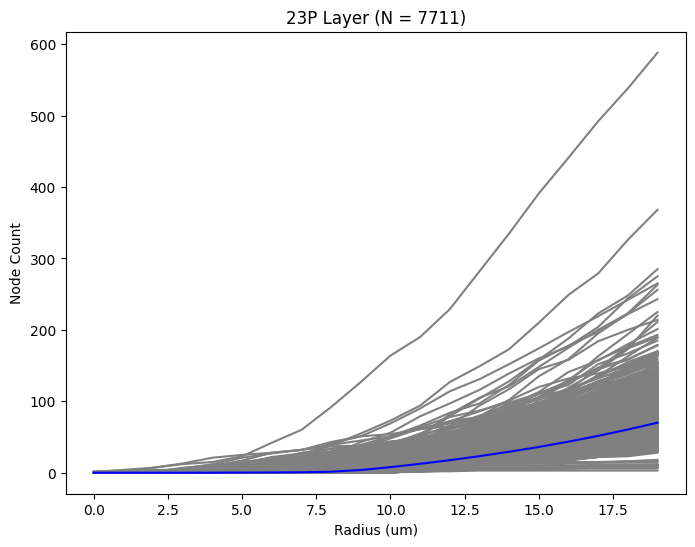

In [10]:
""" Visualization """
dist_all = np.array(list(soma_dist_all_neurons_23P.values()))   # Take only values from dist_all dictionary 
dist_all_avg = np.mean(dist_all, axis = 0)

plt.figure(figsize=(8, 6))

for row in dist_all:
    plt.plot(row, color='gray')
    
plt.plot(dist_all_avg, color = 'blue')
plt.ylabel('Node Count')
plt.xlabel('Radius (um)')
plt.title(f"23P Layer (N = {len(soma_dist_all_neurons_23P)})")
plt.show()

In [11]:
# === Aplying threshold ===

threshold = 5  # µm
mask = (dist_all_df_23P.loc[:, 1:threshold] == 0).all(axis=1)
filtered_23P = dist_all_df_23P[mask]

print(f"Original Neuron List 23P = {len(dist_all_df_23P)}")
print(f"Filtered Neuron List 23P = {len(filtered_23P)}")
list_neurons = filtered_23P.index.to_list()

Original Neuron List 23P = 7711
Filtered Neuron List 23P = 7525


In [12]:
len(list_neurons)

7525

## Step 2: Remove Stumps

This step removes stumps that stick out
Note: all skeletal types are included; no axon or dendrites are selectively filtered

In [13]:
path_raw_sk = "data/data_raw/skeleton/skeleton_raw_swc/"

# Number of nodes over this threshold will be cut
stumps_threshold = 10

for neuron in list_neurons:
    try:
        # Read raw skeleton
        fname = f"{neuron}_sk_swc_raw.csv"
        fpath = os.path.join(path_project, path_raw_sk, fname)
        sk_swc = pd.read_csv(fpath, low_memory=False)

        # stump removal
        dendrite_branches = dd.node_count_dendrite_branches(sk_swc)
        stumps_to_go = {node for node, count in dendrite_branches.items() if count < stumps_threshold}

        # Find all nodes that belong to these short dendrites
        stumps_to_remove = set()
        for node in stumps_to_go:
            stack = [node]
            while stack:
                current_node = stack.pop()
                stumps_to_remove.add(current_node)
    
                # Find children
                children = sk_swc[sk_swc['parent'] == current_node]['id'].tolist()
                stack.extend(children)
        sk_swc = sk_swc[~sk_swc['id'].isin(stumps_to_remove)]

        # Save stump removed skeleton
        path_save = "data/data_processed/neurons_23P_13305/step_2_stump_removal/"

        os.makedirs(os.path.join(path_project, path_save), exist_ok = True)
        out_path = os.path.join(path_project, path_save, f"{neuron}_sk_swc_stump_removed.csv")
        sk_swc.to_csv(out_path, index=False)

    # Throw exception
    except Exception as exc:
        logging.error("✗  Neuron %s FAILED – %s\n%s", neuron, exc, traceback.format_exc(limit=2))

In [14]:
print(f"Number of neurons = {len(list_neurons)}")

Number of neurons = 7525


## Step 3: Dendrite clustering

Label dendrites by dendrites: bifurcation level, distance, segments levels

In [15]:
path_step2 = "data/data_processed/neurons_23P_13305/step_2_stump_removal/"
path_save = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering/"
path_save_visual = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering/validation/"

# ensure output dirs exist
os.makedirs(os.path.join(path_project, path_save), exist_ok=True)
os.makedirs(os.path.join(path_project, path_save_visual), exist_ok=True)

for neuron in tqdm(list_neurons):
    try:
        # load skeleton
        fname = f"{neuron}_sk_swc_stump_removed.csv"
        fpath = os.path.join(path_project, path_step2, fname)
        sk_swc = pd.read_csv(fpath, low_memory=False)

        # Dendrite clustering
        sk_swc_levels = sk_swc.copy()
        sk_swc_levels = dd.assign_branch_order(sk_swc_levels)
        sk_swc_levels = dd.assign_dendrites(sk_swc_levels)
        sk_swc_levels = dd.assign_segments(sk_swc_levels)
        sk_swc_levels = dd.compute_skeleton_tree_distances(sk_swc_levels)

        # # Visualization for validation
        # skp.plot_skeleton_by_levels_2d(sk_swc_levels, "branch_order", "max", neuron, path_project + path_save_visual, True)
        # skp.plot_skeleton_by_levels_2d(sk_swc_levels, "dendrites", "max", neuron, path_project + path_save_visual, True)
        # skp.plot_skeleton_by_levels_2d(sk_swc_levels, "segments", "max", neuron, path_project + path_save_visual, True)
        # skp.plot_skeleton_distance_2d(sk_swc_levels, neuron, path_project + path_save_visual, True, view="xy")


        # Save skeleton
        fname_save = f"{neuron}_sk_swc_dend_clustered.csv"
        out_path = os.path.join(path_project, path_save, fname_save)
        sk_swc_levels.to_csv(out_path, index=False)

    except Exception as exc:
        logging.error("✗  Neuron %s FAILED – %s\n%s", neuron, exc, traceback.format_exc(limit=2))


100%|███████████████████████████████████████| 7525/7525 [47:58<00:00,  2.61it/s]


## Step 4: Removed Fused Neurons

Dendrties not proofread neurons sometimes have dendrites that are not correctly divided or simply wrongly structured.
Sometimes they are fused with astrycytes. To remove these neurons, count dendrites node counds and delete dendrties that surpass certain number 

In [16]:
path_step3 = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering"
path_save  = "data/data_processed/neurons_23P_13305/step_4_remove_fused_neurons/validation"

branch_count_all = {}

for neuron in tqdm(list_neurons):
    fname = f"{neuron}_sk_swc_dend_clustered.csv"
    fpath = os.path.join(path_project, path_step3, fname)
    sk_swc = pd.read_csv(fpath, low_memory=False)

    branch_count_all[neuron] = dd.node_count_dendrite_branches(sk_swc)

# make sure save dir exists
save_dir = os.path.join(path_project, path_save)
os.makedirs(save_dir, exist_ok=True)

# save pickle
out_path = os.path.join(save_dir, "branch_count_only_nonproofread.pkl")
with open(out_path, "wb") as f:
    pickle.dump(branch_count_all, f)


100%|███████████████████████████████████████| 7525/7525 [01:47<00:00, 69.81it/s]


7525


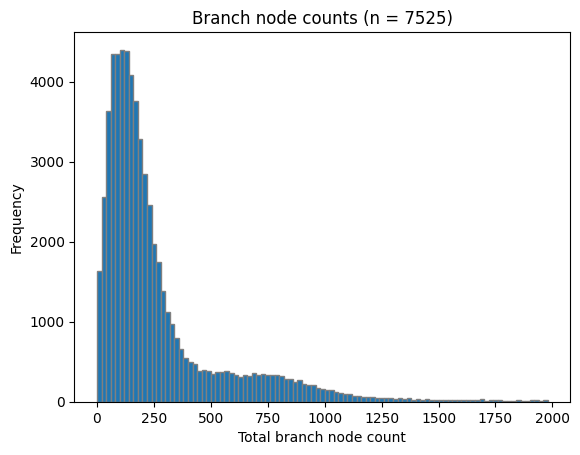

In [17]:
# == Read calculated data ==
path_save = "data/data_processed/neurons_23P_13305/step_4_remove_fused_neurons/validation"
pkl_path = os.path.join(path_project, path_save, "branch_count_only_nonproofread.pkl")

branch_count_all = pd.read_pickle(pkl_path)
print(len(branch_count_all))

# === Visualization ===
branch_node_count_all = [
    count
    for neuron_data in branch_count_all.values()
    for count in neuron_data.values()
]

branch_node_count_np = np.array(branch_node_count_all)

plt.hist(branch_node_count_np, bins=np.arange(0, 2000, 20), edgecolor="grey")
plt.xlabel("Total branch node count")
plt.ylabel("Frequency")
plt.title(f"Branch node counts (n = {len(branch_count_all)})")
plt.show()

In [18]:
# Apply threshold (dendrtie > 1300)
selected_neurons = [] # neuron to remove from list
threshold_dendrite = 1500

for neuron_id, node_counts in branch_count_all.items():
    if any(count > threshold_dendrite for count in node_counts.values()):
        selected_neurons.append(neuron_id)

filtered_try = list(set(list_neurons) - set(selected_neurons))
len(filtered_try)

6389

In [19]:
list_neurons = filtered_try
len(list_neurons)

6389

## Step 5: Assign synapses

In [20]:
# ==== Assign Pre Synapses ===
path_raw_synapse = "data/data_raw/synapse"
path_step3       = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering"
path_save        = "data/data_processed/neurons_23P_13305/step_5_assign_synapses"

# make sure output dir exists once
save_dir = os.path.join(path_project, path_save)
os.makedirs(save_dir, exist_ok=True)

missing_presyn = []
missing_skel = []
failed_other = []
n_saved = 0

for neuron in tqdm(list_neurons):
    try:
        # --- inputs ---
        fname_presynapse = f"{neuron}_pre_synapse_df.pkl"
        fpath_presyn = os.path.join(path_project, path_raw_synapse, fname_presynapse)
        if not os.path.exists(fpath_presyn):
            missing_presyn.append(neuron)
            continue
        pre_synapse_df = pd.read_pickle(fpath_presyn)

        fname_skeleton_levels = f"{neuron}_sk_swc_dend_clustered.csv"
        fpath_skel = os.path.join(path_project, path_step3, fname_skeleton_levels)
        if not os.path.exists(fpath_skel):
            missing_skel.append(neuron)
            continue
        sk_swc_levels = pd.read_csv(fpath_skel, low_memory=False)

        # --- assign synapses to skeleton nodes ---
        assignment_df = dd.synapse_to_skeleton_gpu(pre_synapse_df, sk_swc_levels)

        # --- save ---
        fname_assignment = f"{neuron}_pre_assignment_df.csv"
        out_path = os.path.join(save_dir, fname_assignment)
        assignment_df.to_csv(out_path, index=False)
        n_saved += 1

    except Exception as exc:
        failed_other.append(neuron)
        logging.error("✗  Neuron %s FAILED – %s\n%s", neuron, exc, traceback.format_exc(limit=2))

print("\n=== Step 5 assign synapses report ===")
print("Input neurons:", len(list_neurons))
print("Saved:", n_saved)
print("Missing presynapse:", len(missing_presyn))
print("Missing skeleton:", len(missing_skel))
print("Failed other:", len(failed_other))

100%|███████████████████████████████████████| 6389/6389 [08:01<00:00, 13.26it/s]


=== Step 5 assign synapses report ===
Input neurons: 6389
Saved: 6389
Missing presynapse: 0
Missing skeleton: 0
Failed other: 0


In [21]:
# ==== Assign Post Synapses ===
path_raw_synapse = "data/data_raw/synapse"
path_step3       = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering"
path_save        = "data/data_processed/neurons_23P_13305/step_5_assign_synapses"

save_dir = os.path.join(path_project, path_save)
os.makedirs(save_dir, exist_ok=True)

missing_post = []
missing_skel = []
empty_post = []
bad_skel_csv = []
failed_other = []
n_saved = 0

for neuron in tqdm(list_neurons):
    try:
        # --- postsynapse ---
        fpath_post = os.path.join(path_project, path_raw_synapse, f"{neuron}_post_synapse_df.pkl")
        if not os.path.exists(fpath_post):
            missing_post.append(neuron)
            continue

        post_synapse_df = pd.read_pickle(fpath_post)
        if post_synapse_df is None or post_synapse_df.empty:
            empty_post.append(neuron)
            continue

        # --- skeleton ---
        fpath_skel = os.path.join(path_project, path_step3, f"{neuron}_sk_swc_dend_clustered.csv")
        if not os.path.exists(fpath_skel):
            missing_skel.append(neuron)
            continue

        try:
            sk_swc_levels = pd.read_csv(fpath_skel, low_memory=False)
        except pd.errors.ParserError:
            sk_swc_levels = pd.read_csv(fpath_skel, engine="python")
        except OSError:
            sk_swc_levels = pd.read_csv(fpath_skel, engine="python")

        # extra guard: if skeleton is empty/corrupt in content
        if sk_swc_levels is None or sk_swc_levels.empty:
            bad_skel_csv.append(neuron)
            continue

        # --- assign ---
        assignment_df = dd.post_synapse_to_skeleton_gpu(post_synapse_df, sk_swc_levels)

        # --- save ---
        out_path = os.path.join(save_dir, f"{neuron}_post_assignment_df.csv")
        assignment_df.to_csv(out_path, index=False)
        n_saved += 1

    except Exception as exc:
        failed_other.append(neuron)
        logging.error("✗  Neuron %s FAILED – %s\n%s", neuron, exc, traceback.format_exc(limit=2))

print("\n=== POST synapse assignment report ===")
print("Input neurons:", len(list_neurons))
print("Saved:", n_saved)
print("Missing postsyn:", len(missing_post))
print("Empty postsyn:", len(empty_post))
print("Missing skeleton:", len(missing_skel))
print("Bad/corrupt skeleton CSV:", len(bad_skel_csv))
print("Failed other:", len(failed_other))


100%|██████████████████████████████████████| 6389/6389 [00:52<00:00, 121.77it/s]


=== POST synapse assignment report ===
Input neurons: 6389
Saved: 6389
Missing postsyn: 0
Empty postsyn: 0
Missing skeleton: 0
Bad/corrupt skeleton CSV: 0
Failed other: 0


Found 6389 files
Total files counted: 6389
            neuron_id  n_rows
0  864691136602771153   11249
1  864691135726520639    8178
2  864691135938078468    8177
3  864691135065354820    7999
4  864691134885712378    7859


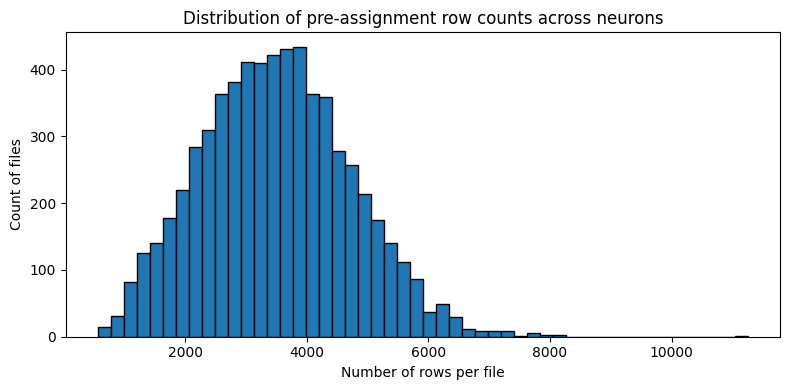

Min rows: 566
Median rows: 3478.0
Max rows: 11249
Zero-row files: 0


In [22]:
# === Sanity check: count rows per pre-assignment file ===
path_save = "data/data_processed/neurons_23P_13305/step_5_assign_synapses"
pattern = "*_pre_assignment_df.csv"

files = glob.glob(os.path.join(path_project, path_save, pattern))
print(f"Found {len(files)} files")

rows_per_file = []

for fpath in files:
    # count lines (minus header)
    with open(fpath, "r", encoding="utf-8", errors="ignore") as fh:
        n_lines = sum(1 for _ in fh)
    n_rows = max(n_lines - 1, 0)

    base = os.path.basename(fpath)
    neuron_id = base.replace("_pre_assignment_df.csv", "")

    rows_per_file.append({"neuron_id": neuron_id, "n_rows": n_rows})

df_counts = (
    pd.DataFrame(rows_per_file)
    .sort_values("n_rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Total files counted: {len(df_counts)}")
print(df_counts.head())

plt.figure(figsize=(8, 4))
plt.hist(df_counts["n_rows"], bins=50, edgecolor="black")
plt.xlabel("Number of rows per file")
plt.ylabel("Count of files")
plt.title("Distribution of pre-assignment row counts across neurons")
plt.tight_layout()
plt.show()

print("Min rows:", df_counts["n_rows"].min())
print("Median rows:", df_counts["n_rows"].median())
print("Max rows:", df_counts["n_rows"].max())
print("Zero-row files:", (df_counts["n_rows"] == 0).sum())

Found 6389 files
Total files counted: 6389
            neuron_id  n_rows
0  864691135777623648     892
1  864691136967796942     767
2  864691135336156649     714
3  864691135916738662     645
4  864691136266425844     631


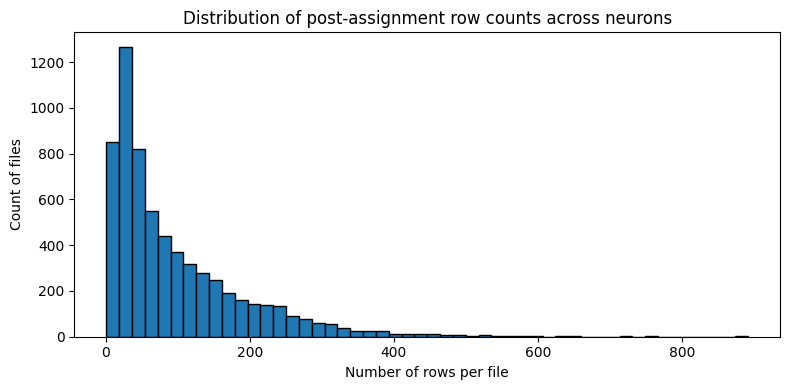

Min rows: 1
Median rows: 62.0
Max rows: 892
Zero-row files: 0


In [23]:
# === Sanity check: count rows per POST-assignment file ===
path_save = "data/data_processed/neurons_23P_13305/step_5_assign_synapses"
pattern = "*_post_assignment_df.csv"

files = glob.glob(os.path.join(path_project, path_save, pattern))
print(f"Found {len(files)} files")

rows_per_file = []

for fpath in files:
    with open(fpath, "r", encoding="utf-8", errors="ignore") as fh:
        n_lines = sum(1 for _ in fh)
    n_rows = max(n_lines - 1, 0)  # subtract header; clamp at 0

    base = os.path.basename(fpath)
    neuron_id = base.replace("_post_assignment_df.csv", "")

    rows_per_file.append({"neuron_id": neuron_id, "n_rows": n_rows})

df_counts_post = (
    pd.DataFrame(rows_per_file)
    .sort_values("n_rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Total files counted: {len(df_counts_post)}")
print(df_counts_post.head())

plt.figure(figsize=(8, 4))
plt.hist(df_counts_post["n_rows"], bins=50, edgecolor="black")
plt.xlabel("Number of rows per file")
plt.ylabel("Count of files")
plt.title("Distribution of post-assignment row counts across neurons")
plt.tight_layout()
plt.show()

# Optional quick summary
print("Min rows:", df_counts_post["n_rows"].min())
print("Median rows:", df_counts_post["n_rows"].median())
print("Max rows:", df_counts_post["n_rows"].max())
print("Zero-row files:", (df_counts_post["n_rows"] == 0).sum())


## Step 6: Combine Assignment (synapse table) and skeleton table

Here since we have seperate table assignment_df and sk_swc_dend_clustered, make a single assignment_df that includes all the features of skeleton from sk_swc_dend_clustered

In [24]:
# == pre assignment df ==

path_step3 = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering"
path_step5 = "data/data_processed/neurons_23P_13305/step_5_assign_synapses"
path_save  = "data/data_processed/neurons_23P_13305/step_6_assign_synapses_clustered"

# ensure output dir exists
save_dir = os.path.join(path_project, path_save)
os.makedirs(save_dir, exist_ok=True)

for neuron in tqdm(list_neurons):
    try:
        # filenames
        fname_ass     = f"{neuron}_pre_assignment_df.csv"
        fname_cluster = f"{neuron}_sk_swc_dend_clustered.csv"

        # paths
        fpath_ass = os.path.join(path_project, path_step5, fname_ass)
        fpath_skel = os.path.join(path_project, path_step3, fname_cluster)

        # load (avoid index_col=0 unless you're 100% sure)
        assignment_df = pd.read_csv(fpath_ass, low_memory=False)
        sk_swc_levels = pd.read_csv(fpath_skel, low_memory=False)

        # Drop 'distance' if present
        if "distance" in assignment_df.columns:
            assignment_df = assignment_df.drop(columns=["distance"])

        # Mapping properties to assignment_df (using YOUR module)
        assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "distance_from_soma", "distance_from_soma")
        assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "branch_order", "branch_order")
        assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "dendrites", "dendrites")
        assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "segments", "segments")

        # save
        out_path = os.path.join(save_dir, f"{neuron}_pre_assignment_df_clustered.csv")
        assignment_df.to_csv(out_path, index=False)

    except FileNotFoundError:
        print(f"File not found for {neuron}, skipping")
        continue
    except Exception as exc:
        logging.error("✗  Neuron %s FAILED – %s\n%s", neuron, exc, traceback.format_exc(limit=2))


100%|██████████████████████████████████████| 6389/6389 [00:57<00:00, 110.59it/s]


In [25]:
# == Post assignment df ==
path_step3 = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering"
path_step5 = "data/data_processed/neurons_23P_13305/step_5_assign_synapses"
path_save  = "data/data_processed/neurons_23P_13305/step_6_assign_synapses_clustered"

# make sure output folder exists
os.makedirs(os.path.join(path_project, path_save), exist_ok=True)

for neuron in tqdm(list_neurons):
    # Read synaptic assignment and clustered skeleton files
    fname_ass = f"{neuron}_post_assignment_df.csv"
    fname_cluster = f"{neuron}_sk_swc_dend_clustered.csv"

    try:
        assignment_df = pd.read_csv(os.path.join(path_project, path_step5, fname_ass), low_memory=False)
        sk_swc_levels = pd.read_csv(os.path.join(path_project, path_step3, fname_cluster), low_memory=False)
    except FileNotFoundError:
        print(f"File not found for {neuron}, skipping")
        continue

    # Drop 'distance' (distance from synapse to assigned skeleton node)
    if "distance" in assignment_df.columns:
        assignment_df = assignment_df.drop(columns=["distance"])

    # Mapping properties to assignment_df (keep using your synapse_anal)
    assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "distance_from_soma", "distance_from_soma")
    assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "branch_order", "branch_order")
    assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "dendrites", "dendrites")
    assignment_df = synapse_anal.assignment_df_mapping(assignment_df, sk_swc_levels, "segments", "segments")

    # Save
    fname_dend = f"{neuron}_post_assignment_df_clustered.csv"
    out_path = os.path.join(path_project, path_save, fname_dend)
    assignment_df.to_csv(out_path, index=False)


100%|██████████████████████████████████████| 6389/6389 [00:24<00:00, 265.77it/s]


Found 6389 files
Total files counted: 6389
            neuron_id  n_rows
0  864691136602771153   11249
1  864691135726520639    8178
2  864691135938078468    8177
3  864691135065354820    7999
4  864691134885712378    7859


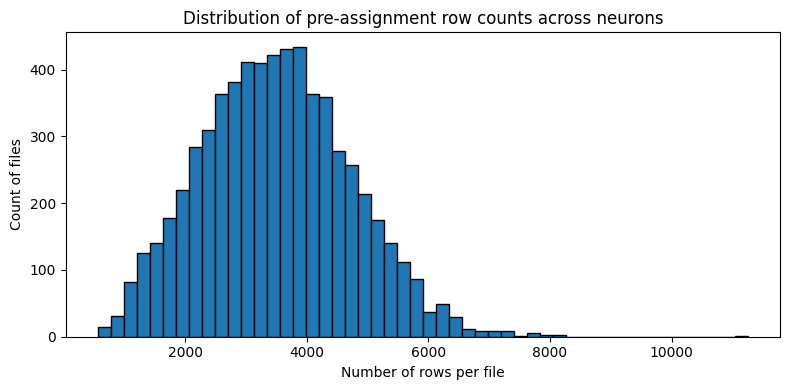

Min rows: 566
Median rows: 3478.0
Max rows: 11249
Zero-row files: 0


In [26]:
# === Sanity check: count rows per pre-assignment file ===
path_save = "data/data_processed/neurons_23P_13305/step_6_assign_synapses_clustered"
pattern = "*_pre_assignment_df_clustered.csv"

files = glob.glob(os.path.join(path_project, path_save, pattern))
print(f"Found {len(files)} files")

rows_per_file = []

for fpath in files:
    # count lines (minus header)
    with open(fpath, "r", encoding="utf-8", errors="ignore") as fh:
        n_lines = sum(1 for _ in fh)
    n_rows = max(n_lines - 1, 0)

    base = os.path.basename(fpath)
    neuron_id = base.replace("_pre_assignment_df_clustered.csv", "")

    rows_per_file.append({"neuron_id": neuron_id, "n_rows": n_rows})

df_counts = (
    pd.DataFrame(rows_per_file)
    .sort_values("n_rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Total files counted: {len(df_counts)}")
print(df_counts.head())

plt.figure(figsize=(8, 4))
plt.hist(df_counts["n_rows"], bins=50, edgecolor="black")
plt.xlabel("Number of rows per file")
plt.ylabel("Count of files")
plt.title("Distribution of pre-assignment row counts across neurons")
plt.tight_layout()
plt.show()

print("Min rows:", df_counts["n_rows"].min())
print("Median rows:", df_counts["n_rows"].median())
print("Max rows:", df_counts["n_rows"].max())
print("Zero-row files:", (df_counts["n_rows"] == 0).sum())

Found 6389 files
Total files counted: 6389
            neuron_id  n_rows
0  864691135777623648     892
1  864691136967796942     767
2  864691135336156649     714
3  864691135916738662     645
4  864691136266425844     631


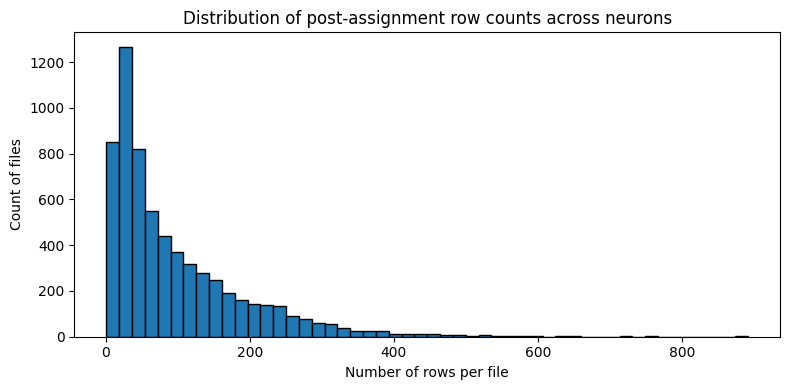

Min rows: 1
Median rows: 62.0
Max rows: 892
Zero-row files: 0


In [27]:
# === Sanity check: count rows per POST-assignment file ===
path_save = "data/data_processed/neurons_23P_13305/step_6_assign_synapses_clustered"
pattern = "*_post_assignment_df_clustered.csv"

files = glob.glob(os.path.join(path_project, path_save, pattern))
print(f"Found {len(files)} files")

rows_per_file = []

for fpath in files:
    with open(fpath, "r", encoding="utf-8", errors="ignore") as fh:
        n_lines = sum(1 for _ in fh)
    n_rows = max(n_lines - 1, 0)  # subtract header; clamp at 0

    base = os.path.basename(fpath)
    neuron_id = base.replace("_post_assignment_df_clustered.csv", "")

    rows_per_file.append({"neuron_id": neuron_id, "n_rows": n_rows})

df_counts_post = (
    pd.DataFrame(rows_per_file)
    .sort_values("n_rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Total files counted: {len(df_counts_post)}")
print(df_counts_post.head())

plt.figure(figsize=(8, 4))
plt.hist(df_counts_post["n_rows"], bins=50, edgecolor="black")
plt.xlabel("Number of rows per file")
plt.ylabel("Count of files")
plt.title("Distribution of post-assignment row counts across neurons")
plt.tight_layout()
plt.show()

# Optional quick summary
print("Min rows:", df_counts_post["n_rows"].min())
print("Median rows:", df_counts_post["n_rows"].median())
print("Max rows:", df_counts_post["n_rows"].max())
print("Zero-row files:", (df_counts_post["n_rows"] == 0).sum())


## Step 7: Label - Axon, Apical, Basal Dendrites

Nonproofread neurons often include axons, that are still classified as dendrite in swc file Calculated pre and post synaptic density for axon distinction

In [28]:
# Calculate synaptic density

path_step6 = "data/data_processed/neurons_23P_13305/step_6_assign_synapses_clustered"
path_step3 = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering"

densities_presynaptic_all = {}
densities_postsynaptic_all = {}

missing = []
failed = []

for neuron in tqdm(list_neurons):
    try:
        # --- Load synapse assignments ---
        f_pre  = os.path.join(path_project, path_step6, f"{neuron}_pre_assignment_df_clustered.csv")
        f_post = os.path.join(path_project, path_step6, f"{neuron}_post_assignment_df_clustered.csv")
        f_sk   = os.path.join(path_project, path_step3, f"{neuron}_sk_swc_dend_clustered.csv")

        if not (os.path.exists(f_pre) and os.path.exists(f_post) and os.path.exists(f_sk)):
            missing.append(neuron)
            continue

        assignment_pre  = pd.read_csv(f_pre,  low_memory=False)
        assignment_post = pd.read_csv(f_post, low_memory=False)
        sk_swc_clustered = pd.read_csv(f_sk,  low_memory=False)

        # --- Ensure dendrite labels are comparable ---
        sk_dend = pd.to_numeric(sk_swc_clustered["dendrites"], errors="coerce").astype("Int64")
        pre_dend = pd.to_numeric(assignment_pre["dendrites"], errors="coerce").astype("Int64")
        post_dend = pd.to_numeric(assignment_post["dendrites"], errors="coerce").astype("Int64")

        # dendrite IDs present in skeleton (exclude -1 and NA)
        dendrite_levels = sorted([int(x) for x in sk_dend.dropna().unique() if int(x) != -1])

        # compute per-dendrite densities
        dens_pre_by_dend = {}
        dens_post_by_dend = {}

        for level in dendrite_levels:
            sk_n = (sk_dend == level).sum()
            if sk_n == 0:
                dens_pre_by_dend[level] = np.nan
                dens_post_by_dend[level] = np.nan
                continue

            n_pre  = (pre_dend == level).sum()
            n_post = (post_dend == level).sum()

            dens_pre_by_dend[level]  = float(n_pre) / float(sk_n)
            dens_post_by_dend[level] = float(n_post) / float(sk_n)

        densities_presynaptic_all[neuron] = dens_pre_by_dend
        densities_postsynaptic_all[neuron] = dens_post_by_dend

    except Exception as e:
        failed.append((neuron, repr(e)))

print("\n=== Density computation report ===")
print("Input neurons:", len(list_neurons))
print("Computed:", len(densities_presynaptic_all))
print("Missing files:", len(missing))
print("Failed:", len(failed))


100%|██████████████████████████████████████| 6389/6389 [00:24<00:00, 262.08it/s]


=== Density computation report ===
Input neurons: 6389
Computed: 6389
Missing files: 0
Failed: 0


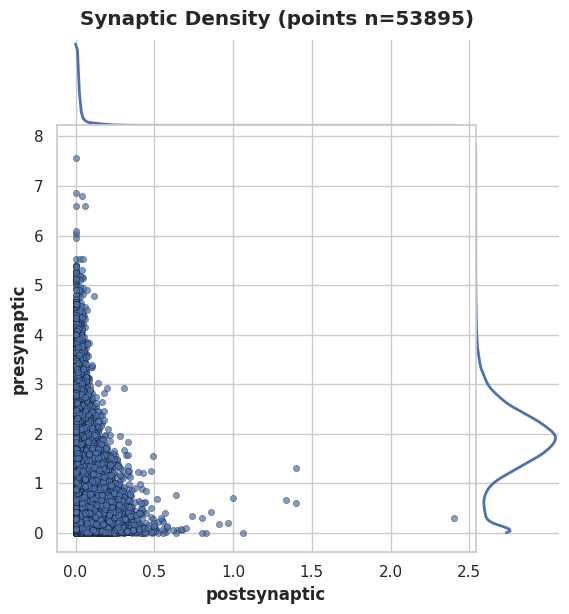

In [29]:
# == Visualization ==

# --- 1) Flatten densities into paired arrays (handles dict or list) ---
pre_values_all = []
post_values_all = []

for neuron in densities_presynaptic_all.keys():
    pre_obj  = densities_presynaptic_all[neuron]
    post_obj = densities_postsynaptic_all[neuron]

    # Case 1: dict per neuron (recommended; aligns by dendrite id)
    if isinstance(pre_obj, dict) and isinstance(post_obj, dict):
        common_levels = sorted(set(pre_obj.keys()) & set(post_obj.keys()))
        pre_values_all.extend([pre_obj[lvl] for lvl in common_levels])
        post_values_all.extend([post_obj[lvl] for lvl in common_levels])

    # Case 2: list/array per neuron (assumes same ordering/length)
    else:
        pre_values_all.extend(list(pre_obj))
        post_values_all.extend(list(post_obj))

x_presyn = np.asarray(pre_values_all, dtype=float)
y_postsyn = np.asarray(post_values_all, dtype=float)

# --- 2) Clean + sanity check ---
if x_presyn.shape[0] != y_postsyn.shape[0]:
    raise ValueError(f"Length mismatch: presyn={len(x_presyn)} vs postsyn={len(y_postsyn)}")

df = pd.DataFrame({"postsyn": y_postsyn, "presyn": x_presyn})
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# --- 3) Plot (JointGrid scatter + KDE marginals) ---
sns.set(style="whitegrid")
g = sns.JointGrid(data=df, x="postsyn", y="presyn", height=6, space=0)

g.plot_joint(
    sns.scatterplot,
    s=20, alpha=0.7, edgecolor="black", linewidth=0.3
)

sns.kdeplot(data=df, x="postsyn", ax=g.ax_marg_x, fill=False, linewidth=2, clip=(0, None))
sns.kdeplot(data=df, y="presyn",  ax=g.ax_marg_y, fill=False, linewidth=2, clip=(0, None))

g.set_axis_labels("postsynaptic", "presynaptic", weight="bold")
g.fig.suptitle(f"Synaptic Density (points n={len(df)})", fontweight="bold", y=1.02)

plt.show()


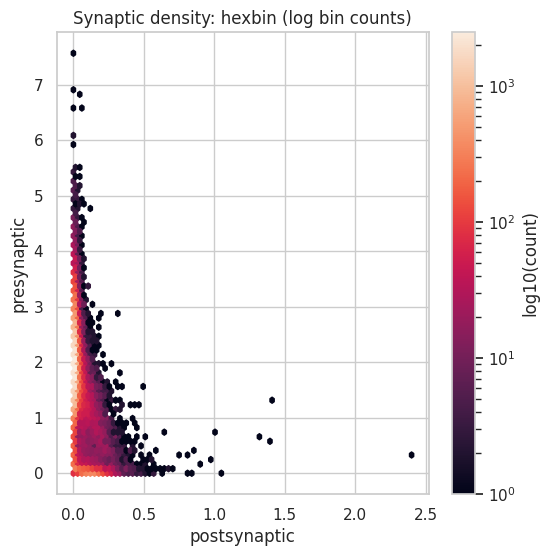

In [30]:
# == Hexbin plot ==
eps = 1e-6
x = y_postsyn
y = x_presyn

plt.figure(figsize=(6,6))
plt.hexbin(x, y, gridsize=80, bins="log")  # log counts per bin
plt.xlabel("postsynaptic")
plt.ylabel("presynaptic")
plt.title("Synaptic density: hexbin (log bin counts)")
plt.colorbar(label="log10(count)")
plt.show()


In [31]:
""" 
1) Label axon by applying threshold (presynaptic density < 0.5)
2) Label apical by marking the largest domain
3) Label rest as basal

['type'] == 2: Axon
['type'] == 3: Basal
['type'] == 4: Apical

"""

# RELATIVE paths (no leading "/")
path_step6 = "data/data_processed/neurons_23P_13305/step_6_assign_synapses_clustered"
path_step3 = "data/data_processed/neurons_23P_13305/step_3_dendrite_clustering"
path_save  = "data/data_processed/neurons_23P_13305/step_7_assign_synapses_xab"

os.makedirs(os.path.join(path_project, path_save), exist_ok=True)

density_threshold = 0.5

for neuron in tqdm(list_neurons):
    try:
        # --- load ---
        f_pre = os.path.join(path_project, path_step6, f"{neuron}_pre_assignment_df_clustered.csv")
        f_sk  = os.path.join(path_project, path_step3, f"{neuron}_sk_swc_dend_clustered.csv")

        assignment_pre = pd.read_csv(f_pre, low_memory=False)
        sk_swc_clustered = pd.read_csv(f_sk, low_memory=False)

        # drop accidental index col if present
        if "Unnamed: 0" in assignment_pre.columns:
            assignment_pre = assignment_pre.drop(columns=["Unnamed: 0"])
        if "Unnamed: 0" in sk_swc_clustered.columns:
            sk_swc_clustered = sk_swc_clustered.drop(columns=["Unnamed: 0"])

        # dendrite IDs from skeleton
        dendrite_levels = pd.to_numeric(sk_swc_clustered["dendrites"], errors="coerce")
        dendrite_levels = dendrite_levels.dropna().astype(int).unique()
        dendrite_levels = [lvl for lvl in dendrite_levels if lvl != -1]

        # init
        assignment_pre["type"] = np.nan

        density_dict = {}
        node_count_dict = {}

        # --- compute density + node counts per dendrite level ---
        for lvl in dendrite_levels:
            sk_n = (sk_swc_clustered["dendrites"] == lvl).sum()
            pre_n = (assignment_pre["dendrites"] == lvl).sum()

            density_pre = (pre_n / sk_n) if sk_n > 0 else np.nan
            density_dict[lvl] = density_pre
            node_count_dict[lvl] = int(sk_n)

            # 1) label axon if density < threshold
            if pd.notna(density_pre) and density_pre < density_threshold:
                assignment_pre.loc[assignment_pre["dendrites"] == lvl, "type"] = 2  # Axon

        # 2) pick apical among non-axon dendrites (type still NaN)
        remaining_lvls = [lvl for lvl in dendrite_levels
                          if assignment_pre.loc[assignment_pre["dendrites"] == lvl, "type"].isna().all()]

        if remaining_lvls:
            apical_level = max(remaining_lvls, key=lambda lvl: node_count_dict.get(lvl, 0))
            assignment_pre.loc[assignment_pre["dendrites"] == apical_level, "type"] = 4  # Apical

        # 3) label rest basal
        for lvl in dendrite_levels:
            if assignment_pre.loc[assignment_pre["dendrites"] == lvl, "type"].isna().all():
                assignment_pre.loc[assignment_pre["dendrites"] == lvl, "type"] = 3  # Basal

        # save
        out_path = os.path.join(path_project, path_save, f"{neuron}_pre_assignment_df_labeled.csv")
        assignment_pre.to_csv(out_path, index=False)

    except Exception as e:
        print(f"Failed for neuron {neuron}: {e}")


100%|███████████████████████████████████████| 6389/6389 [01:09<00:00, 92.11it/s]


Found 6389 files
Total files counted: 6389
            neuron_id  n_rows
0  864691136602771153   11249
1  864691135726520639    8178
2  864691135938078468    8177
3  864691135065354820    7999
4  864691134885712378    7859


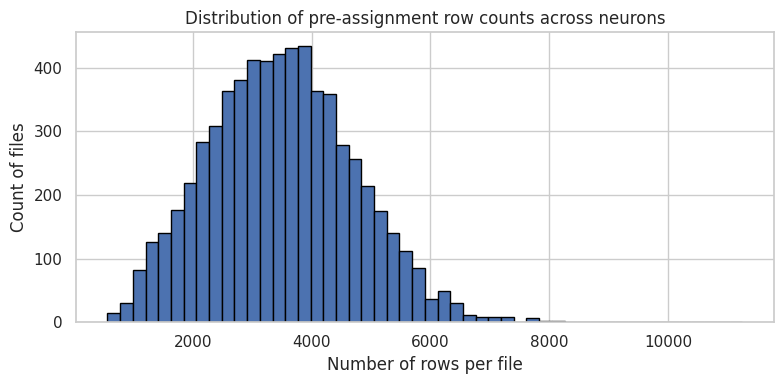

Min rows: 566
Median rows: 3478.0
Max rows: 11249
Zero-row files: 0


In [32]:
# === Sanity check: count rows per pre-assignment file ===
path_save = "data/data_processed/neurons_23P_13305/step_7_assign_synapses_xab"
pattern = "*_pre_assignment_df_labeled.csv"

files = glob.glob(os.path.join(path_project, path_save, pattern))
print(f"Found {len(files)} files")

rows_per_file = []

for fpath in files:
    # count lines (minus header)
    with open(fpath, "r", encoding="utf-8", errors="ignore") as fh:
        n_lines = sum(1 for _ in fh)
    n_rows = max(n_lines - 1, 0)

    base = os.path.basename(fpath)
    neuron_id = base.replace("_pre_assignment_df_labeled.csv", "")

    rows_per_file.append({"neuron_id": neuron_id, "n_rows": n_rows})

df_counts = (
    pd.DataFrame(rows_per_file)
    .sort_values("n_rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Total files counted: {len(df_counts)}")
print(df_counts.head())

plt.figure(figsize=(8, 4))
plt.hist(df_counts["n_rows"], bins=50, edgecolor="black")
plt.xlabel("Number of rows per file")
plt.ylabel("Count of files")
plt.title("Distribution of pre-assignment row counts across neurons")
plt.tight_layout()
plt.show()

print("Min rows:", df_counts["n_rows"].min())
print("Median rows:", df_counts["n_rows"].median())
print("Max rows:", df_counts["n_rows"].max())
print("Zero-row files:", (df_counts["n_rows"] == 0).sum())


## Step 8: Add functional properties and others as well

This is a final step to add all the necessary features for presynaptic and postsynaptic neurons

In [33]:
# -------------------------
# Paths
# -------------------------
path_step7 = "data/data_processed/neurons_23P_13305/step_7_assign_synapses_xab"
path_raw_synapse = "data/data_raw/synapse"
path_save = "data/data_processed/neurons_23P_13305/step_8_full_features/"

os.makedirs(os.path.join(path_project, path_save), exist_ok=True)

# -------------------------
# Precompute lookups ONCE
# -------------------------
# Soma lookup
units_soma = units[["pt_root_id", "pt_position_x", "pt_position_y", "pt_position_z"]].copy()
units_soma = units_soma.drop_duplicates(subset="pt_root_id")
units_soma["pt_root_id"] = pd.to_numeric(units_soma["pt_root_id"], errors="coerce").astype("Int64")

# Strategy lookup
units_strat = units[["pt_root_id", "strategy_axon", "strategy_dendrite"]].copy()
units_strat = units_strat.drop_duplicates(subset="pt_root_id")
units_strat["pt_root_id"] = pd.to_numeric(units_strat["pt_root_id"], errors="coerce").astype("Int64")

# Functional lookup
func_cols = ["pt_root_id", "pref_ori", "pref_dir", "gOSI", "gDSI", "cc_abs"]
func = functional_properties_v3_bcm[func_cols].copy()
func["pt_root_id"] = pd.to_numeric(func["pt_root_id"], errors="coerce").astype("Int64")
func = func.dropna(subset=["pt_root_id"]).drop_duplicates(subset=["pt_root_id"])

# Wrapped diff helper (radians)
def wrap_diff(angle_post, angle_pre, period):
    d = angle_post - angle_pre
    return (d + period / 2) % period - period / 2

# -------------------------
# Loop
# -------------------------
n_saved = 0
n_missing = 0
failed = []

for neuron in tqdm(list_neurons):
    try:
        # -------------------------
        # Load labeled assignment
        # -------------------------
        f_pre = os.path.join(path_project, path_step7, f"{neuron}_pre_assignment_df_labeled.csv")
        assignment_pre = pd.read_csv(f_pre, low_memory=False)

        # Step 1) add post_pt_root_id
        assignment_pre["post_pt_root_id"] = int(neuron)

        # Step 2) type float -> int (nullable int is safest)
        assignment_pre["type"] = pd.to_numeric(assignment_pre["type"], errors="coerce").round().astype("Int64")

        # Step 2.5) cast IDs ONCE (avoid silent merge failures)
        id_cols = ["synapse_id", "pre_pt_root_id", "node_id", "branch_order", "dendrites", "segments", "post_pt_root_id"]
        for c in id_cols:
            if c in assignment_pre.columns:
                assignment_pre[c] = pd.to_numeric(assignment_pre[c], errors="coerce").astype("Int64")

        # ------------------------------------------------
        # Step 3) Soma locations (from units)
        # ------------------------------------------------
        n0 = len(assignment_pre)

        pre_map = units_soma.rename(columns={
            "pt_root_id": "pre_pt_root_id",
            "pt_position_x": "pre_soma_x",
            "pt_position_y": "pre_soma_y",
            "pt_position_z": "pre_soma_z",
        })
        assignment_pre = assignment_pre.merge(pre_map, on="pre_pt_root_id", how="left")
        assert len(assignment_pre) == n0, "Merge explosion in PRE soma merge (duplicate keys?)"

        post_map = units_soma.rename(columns={
            "pt_root_id": "post_pt_root_id",
            "pt_position_x": "post_soma_x",
            "pt_position_y": "post_soma_y",
            "pt_position_z": "post_soma_z",
        })
        assignment_pre = assignment_pre.merge(post_map, on="post_pt_root_id", how="left")
        assert len(assignment_pre) == n0, "Merge explosion in POST soma merge (duplicate keys?)"

        # ------------------------------------------------
        # Step 4) Synapse locations (standard transformed)
        # ------------------------------------------------
        f_syn = os.path.join(path_project, path_raw_synapse, f"{neuron}_pre_synapse_df.pkl")
        pre_synapse_df = pd.read_pickle(f_syn)

        pos_col = "ctr_pt_position" if "ctr_pt_position" in pre_synapse_df.columns else "post_pt_position"

        syn_loc = (
            pre_synapse_df[["id", pos_col]]
            .rename(columns={"id": "synapse_id", pos_col: "pt_position"})
            .drop_duplicates(subset="synapse_id")
        )
        syn_loc["synapse_id"] = pd.to_numeric(syn_loc["synapse_id"], errors="coerce").astype("Int64")

        X_std = minnie_ds.transform_vx.apply_dataframe("pt_position", syn_loc)
        X_std = np.asarray(X_std)

        syn_loc["syp_x"] = X_std[:, 0]
        syn_loc["syp_y"] = X_std[:, 1]
        syn_loc["syp_z"] = X_std[:, 2]

        n0 = len(assignment_pre)
        assignment_pre = assignment_pre.merge(
            syn_loc[["synapse_id", "syp_x", "syp_y", "syp_z"]],
            on="synapse_id",
            how="left",
        )
        assert len(assignment_pre) == n0, "Merge explosion in synapse xyz merge (duplicate synapse_id?)"

        # ------------------------------------------------
        # Step 5) Functional properties
        # ------------------------------------------------
        n0 = len(assignment_pre)

        pre_func = func.rename(columns={
            "pt_root_id": "pre_pt_root_id",
            "pref_ori": "pref_ori_pre",
            "pref_dir": "pref_dir_pre",
            "gOSI": "gOSI_pre",
            "gDSI": "gDSI_pre",
            "cc_abs": "cc_abs_pre",
        })
        assignment_pre = assignment_pre.merge(pre_func, on="pre_pt_root_id", how="left")
        assert len(assignment_pre) == n0, "Merge explosion in PRE functional merge"

        post_func = func.rename(columns={
            "pt_root_id": "post_pt_root_id",
            "pref_ori": "pref_ori_post",
            "pref_dir": "pref_dir_post",
            "gOSI": "gOSI_post",
            "gDSI": "gDSI_post",
            "cc_abs": "cc_abs_post",
        })
        assignment_pre = assignment_pre.merge(post_func, on="post_pt_root_id", how="left")
        assert len(assignment_pre) == n0, "Merge explosion in POST functional merge"

        assignment_pre["pref_ori_diff_wrapped"] = wrap_diff(
            assignment_pre["pref_ori_post"].to_numpy(dtype=float),
            assignment_pre["pref_ori_pre"].to_numpy(dtype=float),
            period=np.pi,
        )
        assignment_pre["pref_dir_diff_wrapped"] = wrap_diff(
            assignment_pre["pref_dir_post"].to_numpy(dtype=float),
            assignment_pre["pref_dir_pre"].to_numpy(dtype=float),
            period=2 * np.pi,
        )

        # ------------------------------------------------
        # Step 6) Proofreading strategy (from units)
        # ------------------------------------------------
        n0 = len(assignment_pre)

        pre_strat = units_strat.rename(columns={
            "pt_root_id": "pre_pt_root_id",
            "strategy_axon": "strat_axon_pre",
        })[["pre_pt_root_id", "strat_axon_pre"]]
        assignment_pre = assignment_pre.merge(pre_strat, on="pre_pt_root_id", how="left")
        assert len(assignment_pre) == n0, "Merge explosion in PRE strategy merge"

        post_strat = units_strat.rename(columns={
            "pt_root_id": "post_pt_root_id",
            "strategy_dendrite": "strat_dendrite_post",
        })[["post_pt_root_id", "strat_dendrite_post"]]
        assignment_pre = assignment_pre.merge(post_strat, on="post_pt_root_id", how="left")
        assert len(assignment_pre) == n0, "Merge explosion in POST strategy merge"

        # ------------------------------------------------
        # Step 7) Save per neuron
        # ------------------------------------------------
        out_path = os.path.join(path_project, path_save, f"{neuron}_pre_assignment_df_full_features.csv")
        assignment_pre.to_csv(out_path, index=False)
        n_saved += 1

    except FileNotFoundError:
        n_missing += 1
        continue
    except Exception as e:
        failed.append((neuron, str(e)))
        print(f"Failed neuron {neuron}: {e}")
        continue

print(f"Done. Saved {n_saved} files. Missing inputs: {n_missing}. Failed: {len(failed)}")
if failed:
    print("Example failures:", failed[:10])


100%|███████████████████████████████████████| 6389/6389 [06:11<00:00, 17.18it/s]

Done. Saved 6389 files. Missing inputs: 0. Failed: 0


Found 6389 files
Total files counted: 6389
            neuron_id  n_rows
0  864691136602771153   11249
1  864691135726520639    8178
2  864691135938078468    8177
3  864691135065354820    7999
4  864691134885712378    7859


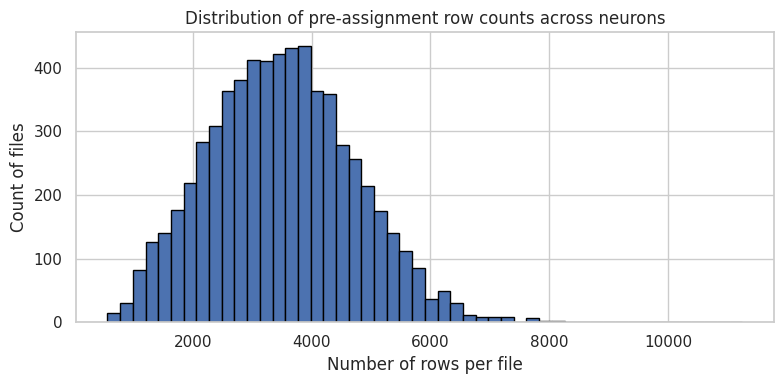

Min rows: 566
Median rows: 3478.0
Max rows: 11249
Zero-row files: 0


In [34]:
# === Sanity check: count rows per pre-assignment file ===
path_save = "data/data_processed/neurons_23P_13305/step_8_full_features"
pattern = "*_pre_assignment_df_full_features.csv"

files = glob.glob(os.path.join(path_project, path_save, pattern))
print(f"Found {len(files)} files")

rows_per_file = []

for fpath in files:
    # count lines (minus header)
    with open(fpath, "r", encoding="utf-8", errors="ignore") as fh:
        n_lines = sum(1 for _ in fh)
    n_rows = max(n_lines - 1, 0)

    base = os.path.basename(fpath)
    neuron_id = base.replace("_pre_assignment_df_full_features.csv", "")

    rows_per_file.append({"neuron_id": neuron_id, "n_rows": n_rows})

df_counts = (
    pd.DataFrame(rows_per_file)
    .sort_values("n_rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Total files counted: {len(df_counts)}")
print(df_counts.head())

plt.figure(figsize=(8, 4))
plt.hist(df_counts["n_rows"], bins=50, edgecolor="black")
plt.xlabel("Number of rows per file")
plt.ylabel("Count of files")
plt.title("Distribution of pre-assignment row counts across neurons")
plt.tight_layout()
plt.show()

print("Min rows:", df_counts["n_rows"].min())
print("Median rows:", df_counts["n_rows"].median())
print("Max rows:", df_counts["n_rows"].max())
print("Zero-row files:", (df_counts["n_rows"] == 0).sum())


## Step 9: Produce one final file

This step will put all the files together into a one giant layer file

In [35]:
path_step8 = "data/data_processed/neurons_23P_13305/step_8_full_features/"
pattern = "*_pre_assignment_df_full_features.csv"

in_files = sorted(glob.glob(os.path.join(path_project, path_step8, pattern)))
print(f"Found {len(in_files)} files")

# ---- output ----
out_path = os.path.join(
    path_project,
    "data/data_processed/neurons_23P_13305/full_features_all_L4_neurons.csv"
)

# ---- concat (memory-friendly incremental write) ----
first = True
total_rows = 0

for f in tqdm(in_files):
    df = pd.read_csv(f, low_memory=False)
    total_rows += len(df)

    df.to_csv(
        out_path,
        mode="w" if first else "a",
        header=first,
        index=False
    )
    first = False

print(f"Saved concatenated CSV: {out_path}")
print(f"Total rows written: {total_rows}")

Found 6389 files


100%|███████████████████████████████████████| 6389/6389 [03:20<00:00, 31.90it/s]

Saved concatenated CSV: /media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/neurons_23P_13305/full_features_all_L4_neurons.csv
Total rows written: 22334076
